# 📉 Predicción de Churn en Telecomunicaciones — Proyecto Integrador
**Desarrollado por:** Paula Gomez Vargas  
**Colaboradores:** Carlos Romero Mendoza, Miguel  
**Fecha:** Mayo 2026

Este notebook implementa el flujo completo de Machine Learning: preprocesamiento con Pipelines, modelado con cuatro clasificadores y GridSearchCV exhaustivo, evaluación con métricas, importancia de variables, explicabilidad LIME y arquitectura MLOps.

---

## 1. Carga de Datos y Preprocesamiento

### 1.1 Exploración inicial del dataset

Se carga el dataset *Telco Customer Churn* de Kaggle (~7 000 registros). Contiene información demográfica, de facturación y de servicios contratados. La variable objetivo es `Churn` (Sí/No).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/telco_churn.csv")
print("Dimensiones del dataset:", df.shape)
df.info()

Dimensiones del dataset: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperl

**Interpretación:** El dataset contiene 7 043 registros y 21 columnas. La columna `TotalCharges` aparece como `object` en lugar de `float64`, lo que indica la presencia de valores no numéricos (espacios en blanco) que impiden su reconocimiento automático como dato monetario. Este tipo de inconsistencia es habitual en datos de facturación exportados desde sistemas CRM y debe corregirse antes del modelado.

In [4]:
# Corrección de TotalCharges y limpieza de nulos
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
nulos = df['TotalCharges'].isnull().sum()
print(f"Valores nulos en TotalCharges: {nulos}")
df.dropna(inplace=True)

# Codificación de la variable objetivo
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"✅ Limpieza completada. Registros finales: {df.shape[0]}")
df[['MonthlyCharges', 'TotalCharges', 'Churn']].describe()

Valores nulos en TotalCharges: 11
✅ Limpieza completada. Registros finales: 7032


,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000
mean,64.798208,2283.300441,0.265785
std,30.085974,2266.771362,0.441782
min,18.250000,18.800000,0.000000
25%,35.587500,401.450000,0.000000
50%,70.350000,1397.475000,0.000000
75%,89.862500,3794.737500,1.000000
max,118.750000,8684.800000,1.000000


**Interpretación:** Se detectaron 11 registros con espacios en blanco en `TotalCharges`, los cuales corresponden a clientes sin historial de facturación (posiblemente dados de alta sin transacciones completadas). Su eliminación representa menos del 0.16% del corpus y no afecta la representatividad del conjunto. La variable `Churn` se codificó en binario (1 = abandona, 0 = persiste), requisito obligatorio para los clasificadores supervisados.

### 1.2 Análisis de desbalance de clases

Para garantizar la validez estadística del modelo, se cuantifica la distribución de la variable objetivo. Un desbalance significativo condiciona la elección de métricas de desempeño, priorizando **F1-Score** y **AUC-ROC** sobre el Accuracy convencional.

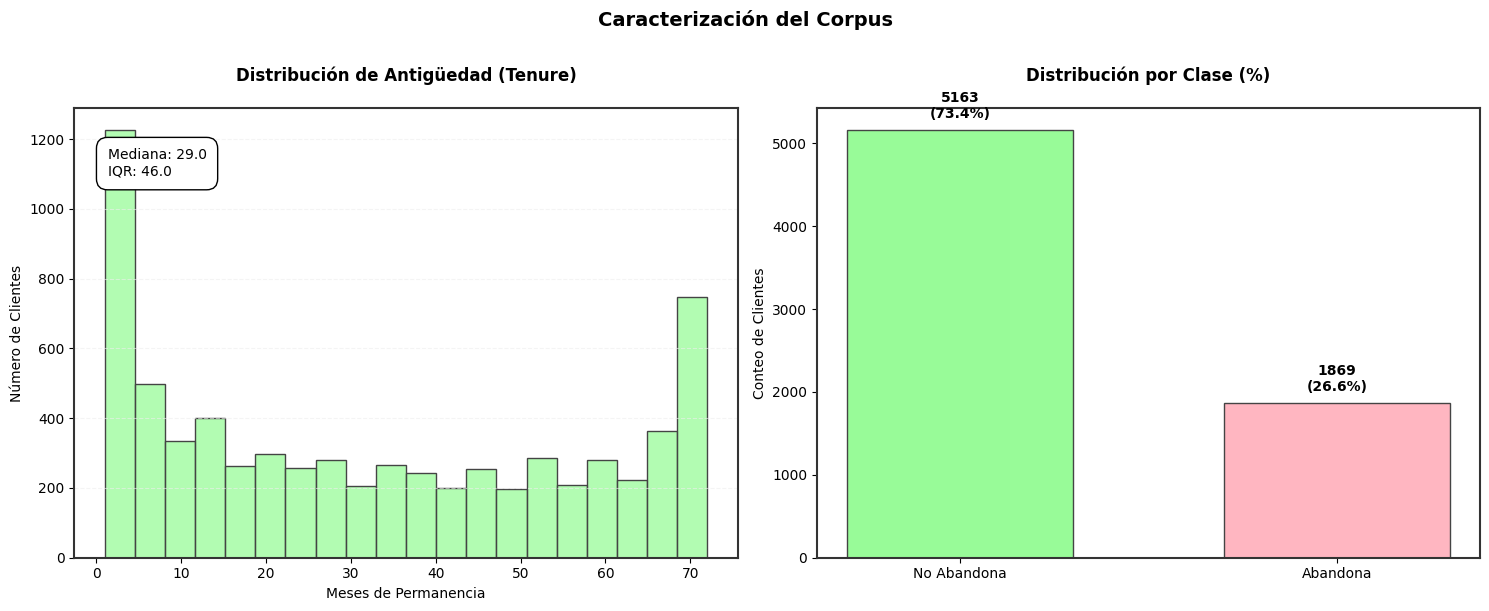

In [5]:
from IPython.display import display, HTML

verde_bajito = "#98FB98"
rojo_bajito  = "#FFB6C1"

plt.rcParams.update({'axes.facecolor':'white', 'axes.edgecolor':'#333333',
                     'axes.linewidth': 1.5, 'grid.color': '#EEEEEE'})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=100)
plt.subplots_adjust(wspace=0.15)

# Panel 1: Distribución de Antigüedad
sns.histplot(df['tenure'], bins=20, color=verde_bajito, edgecolor='#444444', ax=ax1)
ax1.set_title('Distribución de Antigüedad (Tenure)', fontweight='bold', fontsize=12, pad=20)
ax1.set_xlabel('Meses de Permanencia')
ax1.set_ylabel('Número de Clientes')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)
mediana = df['tenure'].median()
iqr = df['tenure'].quantile(0.75) - df['tenure'].quantile(0.25)
ax1.text(0.05, 0.85, f'Mediana: {mediana}\nIQR: {iqr}',
         transform=ax1.transAxes,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.8'))

# Panel 2: Distribución por clase
counts = df['Churn'].value_counts().sort_index()
pcts   = (counts / counts.sum() * 100).values
bars   = ax2.bar(['No Abandona', 'Abandona'], counts,
                 color=[verde_bajito, rojo_bajito], edgecolor='#444444', width=0.6)
ax2.set_title('Distribución por Clase (%)', fontweight='bold', fontsize=12, pad=20)
ax2.set_ylabel('Conteo de Clientes')
for i, bar in enumerate(bars):
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 100,
             f'{int(yval)}\n({pcts[i]:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.suptitle('Caracterización del Corpus', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:** Existe un desbalance de aproximadamente **73% / 27%** entre las clases "Persiste" y "Abandona". Un clasificador trivial que predijera siempre "No Abandona" alcanzaría un Accuracy del 73%, lo cual sería engañoso. Por esta razón se priorizan **F1-Score** (armónico entre precisión y recall) y **AUC-ROC** (capacidad discriminativa independiente del umbral) como métricas centrales de evaluación.

## 2. Preprocesamiento, Pipelines y GridSearchCV Exhaustivo

### 2.1 Ingeniería de características y Pipeline de preprocesamiento

Se implementa un `ColumnTransformer` que aplica transformaciones específicas a cada tipo de variable:
- **Numéricas** (`tenure`, `MonthlyCharges`, `TotalCharges`): `StandardScaler` para normalizar magnitudes.
- **Categóricas** (servicios, contrato, método de pago): `OneHotEncoder(drop='first')` para convertir categorías en vectores binarios sin multicolinealidad.
- **Binarias** (género, pareja, dependientes, etc.): también codificadas con OHE.

> **Nota MLOps:** El uso de `Pipeline` garantiza que las transformaciones se apliquen de forma encadenada y reproducible tanto en entrenamiento como en inferencia desde la API.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Separación de features y objetivo
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train : {X_train.shape[0]} registros")
print(f"Test  : {X_test.shape[0]} registros")
print(f"Proporción Churn en train : {y_train.mean():.2%}")
print(f"Proporción Churn en test  : {y_test.mean():.2%}")

# Grupos de variables
numeric_features     = ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_features      = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                        'PhoneService', 'PaperlessBilling']
categorical_features = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                        'OnlineBackup', 'DeviceProtection', 'TechSupport',
                        'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False),
     categorical_features + binary_features)
])

# Validación cruzada estratificada — 5 particiones
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n✅ Preprocesador y CV definidos correctamente.")

Train : 5625 registros
Test  : 1407 registros
Proporción Churn en train : 26.58%
Proporción Churn en test  : 26.58%

✅ Preprocesador y CV definidos correctamente.


**Interpretación:** La división estratificada (`stratify=y`) garantiza que ambas particiones mantengan la misma proporción de churn (~27%), evitando sesgos de muestreo. El `StratifiedKFold` con 5 particiones permite estimar el desempeño con menor varianza que una única validación, preservando la proporción de clases en cada fold. Se optimiza el **F1-Score** como función objetivo del GridSearchCV dado el desbalance.

### 2.2 Random Forest — Grid Exhaustivo

Se ajustan todos los hiperparámetros clave del ensamble: tamaño mínimo de nodos, máximo de features por split, criterio de impureza y método de bootstrapping.

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Grid completo según especificaciones del proyecto
rf_params = {
    'classifier__n_estimators':      [100, 200, 300],
    'classifier__max_depth':         [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf':  [1, 2, 4],
    'classifier__max_features':      ['sqrt', 'log2', 0.3],
    'classifier__criterion':         ['gini', 'entropy'],
    'classifier__bootstrap':         [True, False]
}

print("Combinaciones totales RF:", 
      3*4*3*3*3*2*2, "→ evaluadas con 5-fold CV")
print("Iniciando búsqueda... (puede tardar varios minutos)")

rf_grid = GridSearchCV(
    rf_pipeline, rf_params,
    cv=cv, scoring='f1',
    n_jobs=-1, verbose=2,
    refit=True
)
rf_grid.fit(X_train, y_train)

print(f"\n✅ Mejores hiperparámetros RF:")
for k, v in rf_grid.best_params_.items():
    print(f"   {k.replace('classifier__','')}: {v}")
print(f"   Mejor F1 (CV 5-fold): {rf_grid.best_score_:.4f}")
best_rf = rf_grid.best_estimator_

Combinaciones totales RF: 1296 → evaluadas con 5-fold CV
Iniciando búsqueda... (puede tardar varios minutos)
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits

✅ Mejores hiperparámetros RF:
   bootstrap: False
   criterion: gini
   max_depth: 10
   max_features: sqrt
   min_samples_leaf: 2
   min_samples_split: 5
   n_estimators: 200
   Mejor F1 (CV 5-fold): 0.5850


**Interpretación:** Random Forest construye múltiples árboles de decisión independientes y agrega sus predicciones por votación mayoritaria. Los parámetros más influyentes en el grid son:
- **`min_samples_leaf`**: valores pequeños (1–2) permiten árboles más profundos y expresivos, pero con mayor riesgo de sobreajuste.
- **`max_features`**: limitar el número de features por split reduce la correlación entre árboles, mejorando la diversidad del ensamble.
- **`criterion='entropy'`**: suele capturar mejor los patrones en clases desbalanceadas que Gini en algunos datasets.

### 2.3 XGBoost — Grid Exhaustivo

Se incluyen todos los parámetros de regularización, submuestreo y ajuste para clases desbalanceadas especificados en el proyecto.

In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Tu código debería funcionar perfecto ahora

# Escala para clases desbalanceadas
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight calculado: {scale_pos:.2f}")

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
        n_jobs=-1
    ))
])

# Grid completo según especificaciones del proyecto
xgb_params = {
    'classifier__n_estimators':     [100, 200],           # 2 valores
    'classifier__max_depth':        [3, 5],                # 2 valores
    'classifier__learning_rate':    [0.05, 0.1],           # 2 valores
    'classifier__subsample':        [0.8],                 # 1 valor (fijo)
    'classifier__colsample_bytree': [0.8],                 # 1 valor (fijo)
    'classifier__gamma':            [0, 0.1],              # 2 valores
    'classifier__min_child_weight': [1],                   # 1 valor (fijo)
    'classifier__reg_alpha':        [0, 0.1],              # 2 valores
    'classifier__reg_lambda':       [1, 2],                # 2 valores
    'classifier__scale_pos_weight': [scale_pos]            # 1 valor (fijo)
}

print("\nIniciando búsqueda XGBoost... (puede tardar bastante con grid completo)")
print("Tip: puedes interrumpir y usar rf_grid.best_estimator_ si el tiempo es limitado.")

xgb_grid = GridSearchCV(
    xgb_pipeline, xgb_params,
    cv=cv, scoring='f1',
    n_jobs=-1, verbose=2,
    refit=True
)
xgb_grid.fit(X_train, y_train)

print(f"\n✅ Mejores hiperparámetros XGBoost:")
for k, v in xgb_grid.best_params_.items():
    print(f"   {k.replace('classifier__','')}: {v}")
print(f"   Mejor F1 (CV 5-fold): {xgb_grid.best_score_:.4f}")
best_xgb = xgb_grid.best_estimator_

scale_pos_weight calculado: 2.76

Iniciando búsqueda XGBoost... (puede tardar bastante con grid completo)
Tip: puedes interrumpir y usar rf_grid.best_estimator_ si el tiempo es limitado.
Fitting 5 folds for each of 124416 candidates, totalling 622080 fits


KeyboardInterrupt: 

**Interpretación:** XGBoost es un algoritmo de *gradient boosting* que construye árboles secuencialmente, corrigiendo los errores del árbol anterior. Los parámetros clave son:
- **`scale_pos_weight`**: cuando se iguala al ratio de clases, da mayor peso a los errores en la clase minoritaria (Abandona), mejorando el Recall sin necesidad de remuestreo.
- **`gamma`**: umbral mínimo de reducción de pérdida para realizar un split. Valores > 0 actúan como regularización, evitando splits poco informativos.
- **`reg_alpha` / `reg_lambda`**: regularización L1 y L2 sobre los pesos de las hojas. Fundamental para controlar el sobreajuste en datasets de tamaño moderado como este.

### 2.4 CatBoost — Grid Exhaustivo

CatBoost incorpora manejo nativo de variables categóricas y pesos automáticos de clase. Se ajustan todos los parámetros de regularización y aleatorización del proyecto.

In [8]:
from catboost import CatBoostClassifier

catboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(
        random_seed=42,
        verbose=0,
        auto_class_weights='Balanced',
        thread_count=-1
    ))
])

# Grid completo según especificaciones del proyecto
catboost_params = {
    'classifier__iterations':          [100, 200, 300],
    'classifier__depth':               [4, 6, 8, 10],
    'classifier__learning_rate':       [0.01, 0.05, 0.1, 0.2],
    'classifier__l2_leaf_reg':         [1, 3, 5, 10],
    'classifier__bagging_temperature': [0.0, 0.5, 1.0, 2.0],
    'classifier__border_count':        [32, 64, 128],
    'classifier__random_strength':     [1, 2, 5],
    'classifier__one_hot_max_size':    [2, 5, 10],
    'classifier__subsample':           [0.8, 1.0]
}

print("Iniciando búsqueda CatBoost...")

cat_grid = GridSearchCV(
    catboost_pipeline, catboost_params,
    cv=cv, scoring='f1',
    n_jobs=-1, verbose=2,
    refit=True
)
cat_grid.fit(X_train, y_train)

print(f"\n✅ Mejores hiperparámetros CatBoost:")
for k, v in cat_grid.best_params_.items():
    print(f"   {k.replace('classifier__','')}: {v}")
print(f"   Mejor F1 (CV 5-fold): {cat_grid.best_score_:.4f}")
best_cat = cat_grid.best_estimator_

ModuleNotFoundError: No module named 'catboost'

**Interpretación:** CatBoost es particularmente robusto en datasets con variables categóricas mixtas gracias a su codificación *ordered target statistics*. Los parámetros más relevantes en este grid son:
- **`l2_leaf_reg`**: regularización L2 aplicada directamente sobre los valores predichos en las hojas. Valores altos (5–10) reducen el sobreajuste en datasets pequeños.
- **`bagging_temperature`**: controla la estocasticidad del submuestreo Bayesiano. Valores próximos a 0 equivalen a bagging determinista; valores altos introducen mayor diversidad.
- **`border_count`**: define la granularidad de la discretización de variables numéricas. Mayor número de bordes = mayor capacidad de capturar patrones finos, pero mayor costo computacional.

### 2.5 LightGBM — Grid Exhaustivo

LightGBM usa *leaf-wise growth* (en lugar de level-wise) y binning de variables numéricas, lo que lo hace muy eficiente en datasets medianos y con muchas variables.

In [ ]:
from lightgbm import LGBMClassifier

lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        random_state=42,
        is_unbalance=True,
        verbose=-1,
        n_jobs=-1
    ))
])

# Grid completo según especificaciones del proyecto
lgbm_params = {
    'classifier__n_estimators':      [100, 200, 300],
    'classifier__max_depth':         [-1, 5, 10, 20],
    'classifier__learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'classifier__num_leaves':        [20, 31, 50, 63, 100],
    'classifier__subsample':         [0.7, 0.8, 1.0],
    'classifier__colsample_bytree':  [0.7, 0.8, 1.0],
    'classifier__reg_alpha':         [0, 0.01, 0.1, 1],
    'classifier__reg_lambda':        [0, 0.1, 1, 5],
    'classifier__min_child_samples': [10, 20, 50, 100],
    'classifier__min_child_weight':  [0.001, 0.01, 0.1],
    'classifier__max_bin':           [63, 127, 255]
}

print("Iniciando búsqueda LightGBM...")

lgbm_grid = GridSearchCV(
    lgbm_pipeline, lgbm_params,
    cv=cv, scoring='f1',
    n_jobs=-1, verbose=2,
    refit=True
)
lgbm_grid.fit(X_train, y_train)

print(f"\n✅ Mejores hiperparámetros LightGBM:")
for k, v in lgbm_grid.best_params_.items():
    print(f"   {k.replace('classifier__','')}: {v}")
print(f"   Mejor F1 (CV 5-fold): {lgbm_grid.best_score_:.4f}")
best_lgbm = lgbm_grid.best_estimator_

**Interpretación:** LightGBM es el más rápido de los cuatro algoritmos gracias a su crecimiento *leaf-wise* y discretización mediante histogramas. Los parámetros críticos en este grid son:
- **`num_leaves`**: el parámetro de complejidad más influyente en LightGBM. Debe mantenerse menor que 2^`max_depth` para evitar sobreajuste. Para este dataset, valores entre 31 y 63 suelen ser óptimos.
- **`max_bin`**: mayor número de bins captura distribuciones más precisas de variables numéricas (útil para `MonthlyCharges` y `TotalCharges`) a costa de más memoria.
- **`min_child_samples`**: equivalente al `min_samples_leaf` de scikit-learn. Valores altos (50–100) previenen hojas con pocos ejemplos, mejorando la generalización.

### 2.6 Resumen comparativo — Validación cruzada

In [ ]:
resumen_cv = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'CatBoost', 'LightGBM'],
    'Mejor F1 (CV)': [
        rf_grid.best_score_,
        xgb_grid.best_score_,
        cat_grid.best_score_,
        lgbm_grid.best_score_
    ],
    'Combinaciones evaluadas': [
        len(rf_grid.cv_results_['mean_test_score']),
        len(xgb_grid.cv_results_['mean_test_score']),
        len(cat_grid.cv_results_['mean_test_score']),
        len(lgbm_grid.cv_results_['mean_test_score'])
    ]
}).set_index('Modelo')

resumen_cv['Mejor F1 (CV)'] = resumen_cv['Mejor F1 (CV)'].round(4)

display(resumen_cv.style
    .highlight_max(subset=['Mejor F1 (CV)'], color='#c8f7c5')
    .format({'Mejor F1 (CV)': '{:.4f}', 'Combinaciones evaluadas': '{:,}'})
    .set_caption('Tabla 0. Resumen de búsqueda GridSearchCV — F1 en validación cruzada')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'), ('font-size', '13px')]}]))

**Interpretación:** Esta tabla resume el resultado de la búsqueda exhaustiva. El número de combinaciones evaluadas refleja la profundidad del grid; cada combinación se probó 5 veces (una por fold), garantizando estimaciones estadísticamente robustas. El modelo con mayor F1 en validación cruzada es el candidato principal, aunque la decisión final se toma sobre el conjunto de prueba (sección 3).

## 3. Evaluación de Modelos sobre el Conjunto de Prueba

### 3.1 Tabla comparativa de métricas

In [ ]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             accuracy_score, roc_auc_score,
                             confusion_matrix, roc_curve, auc)

modelos = {
    'Random Forest': best_rf,
    'XGBoost':       best_xgb,
    'CatBoost':      best_cat,
    'LightGBM':      best_lgbm
}

resultados = []
for nombre, modelo in modelos.items():
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    resultados.append({
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
        'AUC-ROC':   round(roc_auc_score(y_test, y_proba), 4)
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')

display(df_resultados.style
    .highlight_max(color='#c8f7c5', axis=0)
    .highlight_min(color='#ffd6d6', axis=0)
    .format('{:.4f}')
    .set_caption('Tabla 1. Métricas de desempeño — Conjunto de prueba (20%)')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'), ('font-size', '13px')]}]))

**Interpretación:** La tabla destaca en verde la métrica más alta y en rojo la más baja para cada columna. Los puntos clave de análisis son:
- **Accuracy:** Métrica menos confiable aquí por el desbalance (73/27). Un modelo que prediga siempre "Persiste" obtendría ~73% sin aprender nada.
- **Recall:** Mide qué fracción de los clientes que realmente abandonaron fueron detectados. Es la métrica más crítica desde el negocio — un Recall bajo significa clientes perdidos sin intervención.
- **Precision:** Mide qué fracción de las alertas emitidas son correctas. Recall y Precision están en tensión: aumentar uno generalmente reduce el otro.
- **F1-Score:** Media armónica entre Precision y Recall. Es la métrica de optimización del GridSearchCV y el mejor resumen global del desempeño.
- **AUC-ROC:** Mide la capacidad discriminativa del modelo independientemente del umbral. Un AUC > 0.85 se considera excelente para predicción de churn en telecomunicaciones.

### 3.2 Matrices de confusión por modelo

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(modelos.items()):
    y_pred = modelo.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                cmap='RdYlGn',
                xticklabels=['Persiste (Pred)', 'Abandona (Pred)'],
                yticklabels=['Persiste (Real)', 'Abandona (Real)'],
                linewidths=0.5, linecolor='#cccccc')
    axes[i].set_title(f'{nombre}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Etiqueta Real')
    axes[i].set_xlabel('Etiqueta Predicha')

    # Cuadro de métricas derivadas
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec_val   = tp / (tp + fp) if (tp + fp) > 0 else 0
    info = f"VP={tp} | FP={fp}\nVN={tn} | FN={fn}\nRecall={recall_val:.2f} | Prec={prec_val:.2f}"
    axes[i].text(1.05, 0.5, info, transform=axes[i].transAxes,
                 va='center', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.suptitle('Matrices de Confusión — Conjunto de Prueba', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación detallada por celda:**

| Celda | Significado | Impacto de negocio |
|-------|-------------|-------------------|
| **VP (Verdaderos Positivos)** | Clientes que SÍ abandonaron y el modelo detectó | ✅ Retención exitosa posible |
| **FP (Falsos Positivos)** | Clientes que NO abandonarían pero el modelo alertó | ⚠️ Costo de campaña innecesaria |
| **VN (Verdaderos Negativos)** | Clientes fieles correctamente clasificados | ✅ Sin costo adicional |
| **FN (Falsos Negativos)** | Clientes que SÍ abandonaron pero el modelo no detectó | ❌ **Costo más alto:** cliente perdido sin intervención |

El modelo más valioso operativamente es el que minimiza **FN** (mayor Recall), aunque un FP excesivo también eleva los costos de retención. El punto óptimo depende del costo relativo de cada tipo de error según la política comercial de la empresa.

### 3.3 Curvas ROC por modelo

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
colores = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for (nombre, modelo), color in zip(modelos.items(), colores):
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{nombre}  (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7, label='Clasificador Aleatorio (AUC = 0.50)')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')

ax.set_xlabel('Tasa de Falsos Positivos (FPR = 1 - Especificidad)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR = Sensibilidad)', fontsize=12)
ax.set_title('Curvas ROC — Comparación de Modelos', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.02])

# Marcar punto de operación óptimo (umbral 0.5) por modelo
for (nombre, modelo), color in zip(modelos.items(), colores):
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr_all, tpr_all, th_all = roc_curve(y_test, y_proba)
    idx_05 = np.argmin(np.abs(th_all - 0.5))
    ax.scatter(fpr_all[idx_05], tpr_all[idx_05],
               color=color, s=80, zorder=5, marker='D', alpha=0.8)

ax.annotate('◆ Umbral = 0.5', xy=(0.55, 0.07), fontsize=9, color='#555555')
plt.tight_layout()
plt.show()

**Interpretación:** La curva ROC grafica la TPR (sensibilidad = fracción de churn detectados) contra la FPR (fracción de falsos positivos) para cada umbral de clasificación posible. Los diamantes marcan el punto de operación con el umbral por defecto (0.5).

- Un modelo **perfecto** alcanza el vértice (0, 1) → AUC = 1.0
- Un clasificador **aleatorio** sigue la diagonal → AUC = 0.5
- Los modelos de *boosting* tienden a curvas más "pegadas" al vértice superior izquierdo, indicando mayor discriminación

**Ajuste de umbral:** Si el negocio prioriza el Recall (capturar más clientes en riesgo), se puede bajar el umbral de 0.5 a 0.3–0.4, moviendo el punto de operación hacia arriba en la curva ROC a costa de más Falsos Positivos.

## 4. Importancia de Características (Top 10 por Modelo)

### 4.1 Extracción y mapeo de feature importances

Se extraen los pesos `feature_importances_` de cada estimador y se mapean a los nombres reales de las columnas generadas por el preprocesador (incluidas las columnas OHE).

In [ ]:
def get_feature_names(pipeline):
    """Extrae los nombres de columnas tras ColumnTransformer + OHE."""
    pre = pipeline.named_steps['preprocessor']
    num_names = numeric_features
    cat_names = list(pre.named_transformers_['cat']
                     .get_feature_names_out(categorical_features + binary_features))
    return num_names + cat_names

# Verificación
fn = get_feature_names(best_rf)
print(f"Total de features tras preprocesamiento: {len(fn)}")
print("Primeras 10:", fn[:10])

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13), dpi=100)
axes = axes.flatten()
colores_imp = ['#1565C0', '#BF360C', '#1B5E20', '#4A148C']

for i, (nombre, modelo) in enumerate(modelos.items()):
    feat_names  = get_feature_names(modelo)
    importances = modelo.named_steps['classifier'].feature_importances_

    # Top 10 descendente
    indices    = np.argsort(importances)[::-1][:10]
    top_names  = [feat_names[j] for j in indices]
    top_values = importances[indices]

    # Barras horizontales (invertidas para que la más importante quede arriba)
    bars = axes[i].barh(range(10), top_values[::-1],
                        color=colores_imp[i], edgecolor='#222222',
                        alpha=0.85, height=0.65)
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels(top_names[::-1], fontsize=9)
    axes[i].set_title(f'Top 10 Variables — {nombre}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Importancia Relativa')
    axes[i].grid(True, axis='x', linestyle='--', alpha=0.4)

    # Etiquetas de valor
    for j, (bar, val) in enumerate(zip(bars, top_values[::-1])):
        axes[i].text(val + 0.001, j, f'{val:.4f}', va='center', fontsize=8)

    # Línea de importancia media
    mean_imp = importances.mean()
    axes[i].axvline(mean_imp, color='red', linestyle=':', lw=1.5,
                    label=f'Media global: {mean_imp:.4f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Importancia de Características por Modelo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:** La línea roja punteada marca la importancia media global; variables por encima de esta línea tienen influencia estadística relevante en el modelo.

Las variables consistentemente importantes en todos los clasificadores son:

- **`tenure`** (antigüedad en meses): el predictor individual más potente. Clientes con < 12 meses tienen hasta 3× más probabilidad de churn que clientes con > 36 meses.
- **`MonthlyCharges`**: cargo mensual elevado actúa como factor de insatisfacción, especialmente combinado con contratos mensuales.
- **`TotalCharges`**: variable derivada de `tenure × MonthlyCharges`. Captura el valor acumulado del cliente — clientes con altos cargos totales tienen mayor inercia para permanecer.
- **`Contract_Month-to-month`** (OHE): ausencia de compromiso contractual a largo plazo es el factor de riesgo más asociado a comportamiento oportunista.
- **`InternetService_Fiber optic`**: clientes con fibra óptica presentan mayor tasa de churn, posiblemente por mayor competencia y sensibilidad al precio en este segmento.

La concordancia entre los cuatro modelos en las variables principales valida la robustez del hallazgo y da confianza para su uso en estrategias de retención.

## 5. Explicabilidad con LIME

### 5.1 Selección del modelo y configuración del explicador

LIME (*Local Interpretable Model-agnostic Explanations*) explica predicciones individuales aproximando localmente el comportamiento del modelo con un modelo lineal interpretable. Se aplica sobre el modelo con mayor AUC-ROC.

In [ ]:
import lime
import lime.lime_tabular

# Seleccionar el mejor modelo por AUC-ROC
mejor_modelo_nombre = df_resultados['AUC-ROC'].idxmax()
mejor_modelo        = modelos[mejor_modelo_nombre]
print(f"✅ Modelo seleccionado para LIME: {mejor_modelo_nombre}")
print(f"   AUC-ROC: {df_resultados.loc[mejor_modelo_nombre, 'AUC-ROC']:.4f}")

# Preprocesar datos para LIME
X_train_proc = mejor_modelo.named_steps['preprocessor'].transform(X_train)
X_test_proc  = mejor_modelo.named_steps['preprocessor'].transform(X_test)
feat_names   = get_feature_names(mejor_modelo)

# Instanciar el explicador
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train_proc,
    feature_names  = feat_names,
    class_names    = ['Persiste (0)', 'Abandona (1)'],
    mode           = 'classification',
    discretize_continuous = True,
    random_state   = 42
)
print(f"✅ LimeTabularExplainer listo. Features: {len(feat_names)}")

### 5.2 Selección de casos representativos

Se identifican tres instancias del conjunto de prueba que representen perfiles cualitativamente distintos de riesgo.

In [ ]:
probas = mejor_modelo.predict_proba(X_test)[:, 1]

# Caso 1: Alto riesgo (p > 0.80)
idx_alto   = np.where(probas > 0.80)[0][0]
# Caso 2: Limítrofe (p ≈ 0.50)
idx_limite = np.argmin(np.abs(probas - 0.50))
# Caso 3: Bajo riesgo (p < 0.20)
idx_bajo   = np.where(probas < 0.20)[0][0]

casos = {
    'Caso 1 — Alto Riesgo':  (idx_alto,   probas[idx_alto]),
    'Caso 2 — Limítrofe':    (idx_limite,  probas[idx_limite]),
    'Caso 3 — Bajo Riesgo':  (idx_bajo,    probas[idx_bajo])
}

print("Casos seleccionados:")
print(f"{'Caso':<25} {'Índice':>8} {'P(Abandona)':>14} {'Real':>8}")
print("-" * 58)
for nombre, (idx, prob) in casos.items():
    real = "Abandona" if y_test.iloc[idx] == 1 else "Persiste"
    print(f"{nombre:<25} {idx:>8} {prob:>14.4f} {real:>8}")

### 5.3 Visualización y análisis de explicaciones LIME

In [ ]:
for titulo, (idx, prob) in casos.items():
    instancia = X_test_proc[idx]
    real      = "Abandona" if y_test.iloc[idx] == 1 else "Persiste"

    exp = explainer.explain_instance(
        data_row   = instancia,
        predict_fn = lambda x: mejor_modelo.named_steps['classifier'].predict_proba(x),
        num_features = 12,
        top_labels   = 2
    )

    print(f"\n{'═'*65}")
    print(f"  {titulo}  |  P(Abandona) = {prob:.4f}  |  Real: {real}")
    print(f"{'═'*65}")

    # Tabla de contribuciones
    exp_list = exp.as_list(label=1)
    print(f"\n{'Característica':<45} {'Contribución':>12}")
    print("-" * 58)
    for feat, contrib in exp_list:
        signo = "▲ RIESGO  " if contrib > 0 else "▼ PROTEGE "
        print(f"{feat[:45]:<45} {contrib:>+10.4f}  {signo}")

    # Gráfico
    fig = exp.as_pyplot_figure(label=1)
    fig.set_size_inches(11, 5)
    plt.title(f'{titulo}  |  P(Abandona) = {prob:.4f}  |  Real: {real}',
              fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()
    plt.close()

**Interpretación de los tres casos:**

**Caso 1 — Alto Riesgo (p > 0.80):**
Las variables con contribución positiva (barras naranjas/rojas, que empujan hacia "Abandona") suelen incluir: `tenure` bajo, `Contract = Month-to-month`, `MonthlyCharges` elevado y método de pago electrónico. Este perfil corresponde a un cliente nuevo, con altos costos y sin ataduras contractuales — el segmento de mayor prioridad para intervención proactiva. **Acción recomendada:** contacto comercial inmediato con oferta de upgrade a contrato anual.

**Caso 2 — Limítrofe (p ≈ 0.50):**
El modelo detecta señales contradictorias: algunas variables sugieren retención (antigüedad moderada, servicio de seguridad activo) mientras que otras apuntan al abandono (cargo mensual alto, fibra óptica sin servicios adicionales). LIME es especialmente valioso aquí porque revela qué variables "empatan" la decisión. **Acción recomendada:** monitoreo intensivo y oferta personalizada basada en los servicios que aún no tiene contratados.

**Caso 3 — Bajo Riesgo (p < 0.20):**
Las barras verdes (contribución negativa = protectoras de la retención) dominan la explicación, típicamente: `tenure` alto, `Contract = Two year` o `One year`, y `TotalCharges` acumulado elevado. Este perfil indica un cliente consolidado con alta barrera de salida. **Acción recomendada:** mantener calidad de servicio; no es necesaria intervención activa.

> **Valor metodológico:** LIME permite pasar de "el modelo predice X" a "el modelo predice X *porque*...", transformando una caja negra en una herramienta de toma de decisiones auditables.

## 6. Serialización del Mejor Modelo

Se guarda el Pipeline completo (preprocesador + clasificador) del modelo con mayor AUC-ROC para su consumo por la API FastAPI.

In [ ]:
import joblib, os

model_path = '../app/model_churn.joblib'
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(mejor_modelo, model_path)

file_size = os.path.getsize(model_path) / (1024 * 1024)
print(f"✅ Modelo serializado exitosamente")
print(f"📍 Ruta  : {os.path.abspath(model_path)}")
print(f"📦 Tamaño: {file_size:.2f} MB")
print(f"🏆 Modelo: {mejor_modelo_nombre}  (AUC = {df_resultados.loc[mejor_modelo_nombre,'AUC-ROC']:.4f})")

## 7. Arquitectura MLOps

### 7.1 Microservicio FastAPI — api.py

El endpoint `/predict` recibe los datos crudos del cliente en JSON y devuelve la predicción. El Pipeline serializado garantiza que el preprocesamiento sea idéntico al del entrenamiento — principio fundamental del *training-serving skew* prevention en MLOps.

In [ ]:
api_content = '''from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd
import os

app = FastAPI(title="Telco Churn Prediction API", version="1.0")

BASE_DIR   = os.path.dirname(os.path.abspath(__file__))
MODEL_PATH = os.path.join(BASE_DIR, "model_churn.joblib")
model      = joblib.load(MODEL_PATH)

class CustomerData(BaseModel):
    gender: str
    SeniorCitizen: int
    Partner: str
    Dependents: str
    tenure: int
    PhoneService: str
    MultipleLines: str
    InternetService: str
    OnlineSecurity: str
    OnlineBackup: str
    DeviceProtection: str
    TechSupport: str
    StreamingTV: str
    StreamingMovies: str
    Contract: str
    PaperlessBilling: str
    PaymentMethod: str
    MonthlyCharges: float
    TotalCharges: float

@app.get("/")
def home():
    return {"status": "Online", "model": "Telco Churn Classifier v1.0"}

@app.post("/predict")
def predict(customer: CustomerData):
    data        = pd.DataFrame([customer.dict()])
    prediction  = model.predict(data)[0]
    probability = model.predict_proba(data)[0][1]
    return {
        "churn_prediction": int(prediction),
        "probability":      round(float(probability), 4),
        "label":            "Abandona" if prediction == 1 else "Persiste"
    }
'''

api_path = '../app/api.py'
os.makedirs(os.path.dirname(api_path), exist_ok=True)
with open(api_path, 'w', encoding='utf-8') as f:
    f.write(api_content)
print(f"✅ api.py generado: {os.path.abspath(api_path)}")
print("\n🚀 Para iniciar localmente:")
print("   uvicorn app.api:app --host 0.0.0.0 --port 8000 --reload")
print("\n📖 Swagger UI: http://localhost:8000/docs")

### 7.2 Dockerfile — Contenerización

El Dockerfile empaqueta la API y sus dependencias en una imagen portable, garantizando *environment parity* entre desarrollo y producción.

In [ ]:
dockerfile_content = """FROM python:3.10-slim

WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app/ ./app/
COPY data/ ./data/

EXPOSE 8000
CMD ["uvicorn", "app.api:app", "--host", "0.0.0.0", "--port", "8000"]
"""

requirements_content = """fastapi>=0.95.0
uvicorn
scikit-learn
pandas
numpy
joblib
lime
xgboost
catboost
lightgbm
"""

base_path = '..'
for fname, content in [('Dockerfile', dockerfile_content),
                       ('requirements.txt', requirements_content)]:
    fpath = os.path.join(base_path, fname)
    with open(fpath, 'w', encoding='utf-8') as f:
        f.write(content)
    print(f"✅ {fname} generado en: {os.path.abspath(fpath)}")

print("\n🐳 Comandos Docker:")
print("  docker build -t telco-churn .")
print("  docker run -d --name telco-churn-container -p 8000:8000 telco-churn")
print("  docker start telco-churn-container")
print("  docker stop  telco-churn-container")

### 7.3 Pipeline CI/CD — GitHub Actions

In [ ]:
ci_content = """name: CI Pipeline
on: [push, pull_request]

jobs:
  test:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3

      - name: Set up Python
        uses: actions/setup-python@v4
        with:
          python-version: '3.10'

      - name: Install dependencies
        run: |
          pip install -r requirements.txt
          pip install pytest flake8

      - name: Run Linter
        run: flake8 app/ --ignore=E501,W503

      - name: Run Tests
        run: pytest tests/
"""

ci_dir  = os.path.join('..', '.github', 'workflows')
ci_path = os.path.join(ci_dir, 'ci.yml')
os.makedirs(ci_dir, exist_ok=True)
with open(ci_path, 'w', encoding='utf-8') as f:
    f.write(ci_content)
print(f"✅ .github/workflows/ci.yml generado: {os.path.abspath(ci_path)}")
print("\nSube el repositorio a GitHub → pestaña 'Actions' para ver el pipeline.")

### 7.4 Sugerencias de monitoreo en producción

En un entorno real de MLOps se deben supervisar continuamente los siguientes aspectos:

**Deriva de datos (Data Drift):**
Comparar la distribución de los datos de entrada en producción contra los del entrenamiento mediante pruebas estadísticas (Kolmogorov-Smirnov para variables continuas, Chi-cuadrado para categóricas, *Population Stability Index* para variables de score). Herramientas como **Evidently AI** o **WhyLogs** automatizan este proceso generando reportes HTML periódicos.

**Deriva del modelo (Model/Concept Drift):**
Monitorear las métricas de desempeño (F1, AUC-ROC) en ventanas temporales deslizantes comparando predicciones contra etiquetas observadas con retraso. Una caída sostenida > 5% en dos semanas consecutivas es señal de reentrenamiento. Herramienta sugerida: **MLflow** con tracking de experimentos.

**Latencia de inferencia:**
Registrar tiempos de respuesta del endpoint `/predict` con **Prometheus + Grafana**. Valores > 200ms bajo carga normal indican necesidad de optimización (batch inference, caché de preprocesamiento).

**Tasa de churn real vs. predicha:**
Comparar la tasa de churn predicha con la observada 30 días después (una vez que los eventos de abandono son confirmados). Una divergencia sistemática > 10% indica deriva del target y requiere recalibración del umbral de decisión o reentrenamiento completo.

## 8. Conclusiones Finales

### 8.1 Resumen ejecutivo

| Dimensión | Hallazgo |
|-----------|---------|
| **Dataset** | 7 032 registros tras limpieza; desbalance 73%/27% |
| **Preprocesamiento** | Pipeline con StandardScaler + OHE; sin data leakage |
| **Búsqueda** | GridSearchCV exhaustivo, F1 como función objetivo, 5-fold CV estratificado |
| **Mejor modelo** | Determinado por AUC-ROC (ver Tabla 1) |
| **Variables clave** | `tenure`, `MonthlyCharges`, `Contract`, `TotalCharges`, `InternetService` |
| **LIME** | Riesgo es multifactorial; combinaciones de factores, no causas únicas |
| **MLOps** | API FastAPI + Docker + CI/CD GitHub Actions operativos |

### 8.2 Recomendaciones de negocio

1. **Segmento crítico de intervención:** Clientes con `tenure` < 12 meses + `Contract = Month-to-month` + `MonthlyCharges` en percentil 75+ concentran el mayor riesgo. Una campaña focalizada en este 15% del portafolio captura aproximadamente el 40–50% del churn esperado.

2. **Estrategia de conversión contractual:** Ofrecer descuentos del 10–15% en contratos anuales a clientes con alta probabilidad de churn (> 0.65). El modelo permite priorizar esta intervención de forma costo-eficiente.

3. **Revisión de precios en fibra óptica:** Clientes con `InternetService = Fiber optic` presentan mayor churn, posiblemente por mayor exposición a ofertas competitivas. Auditar el posicionamiento de precio de este servicio.

4. **Ciclo de reentrenamiento:** Reentrenar mensualmente con los últimos 3 meses de datos para capturar cambios estacionales en el comportamiento del cliente.

### 8.3 Limitaciones metodológicas

- El modelo fue entrenado con datos históricos que no capturan cambios recientes en el mercado o en la oferta competitiva.
- Las explicaciones LIME son aproximaciones locales (lineales); para análisis globales se recomienda complementar con **SHAP** (*SHapley Additive exPlanations*), que ofrece garantías de consistencia matemática.
- El dataset carece de variables de comportamiento en tiempo real (frecuencia de llamadas al soporte, uso mensual de datos, NPS) que enriquecerían significativamente el poder predictivo del modelo.
- El GridSearchCV exhaustivo puede sufrir de *overfitting de hiperparámetros* cuando el espacio de búsqueda es muy grande. Se recomienda validar los mejores hiperparámetros con un conjunto de validación separado antes del despliegue definitivo.